# 신용카드 고객 이탈 예측 프로젝트
## 4. 회귀 

데이터: `data/bankchurners_clean.csv`

타겟: `Total_Trans_Ct` (최근 12개월 총 거래건수)

**전체 흐름**
1. 데이터 로드 & Train(60%)/Validation(20%)/Test(20%) 분할
2. 베이스라인 모델 비교 (원본 피처, 기본 파라미터)
3. **고도화** — 피처 엔지니어링 → 하이퍼파라미터 튜닝 → 앙상블 학습 (한 파트로 묶어서 순차 진행)
4. 최종 모델 확정 및 전체 방법 종합 비교 (Val R² / Test R² 모두 표기)
5. Feature Importance
6. 비즈니스 적용 (활동성 갭, 조기경보, 우량 고객 발굴)

## 0. 라이브러리 & 데이터 로드

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn import set_config
set_config(display="text")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

## 1. Train(60%) / Validation(20%) / Test(20%) 분할 — 원본 피처 기준

먼저 피처 엔지니어링을 적용하지 않은 원본 피처로 분할함. 이후 '고도화' 파트에서 파생변수를 추가한 뒤에는 같은 고객(같은 인덱스) 기준으로 다시 나눠 비교함.

In [5]:
X_raw = df.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
y = df["Total_Trans_Ct"]
cat_cols_raw = X_raw.select_dtypes(include="object").columns.tolist()
X_raw = pd.get_dummies(X_raw, columns=cat_cols_raw, drop_first=True)

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_trainval_raw, y_trainval, test_size=0.25, random_state=42)

print(f"Train: {X_train_raw.shape[0]}건(60%) / Validation: {X_val_raw.shape[0]}건(20%) / Test: {X_test_raw.shape[0]}건(20%)")

Train: 6075건(60%) / Validation: 2026건(20%) / Test: 2026건(20%)


C:\Users\UK\AppData\Local\Temp\ipykernel_51500\4202954161.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_raw = X_raw.select_dtypes(include="object").columns.tolist()


## 2. 베이스라인 모델 비교 (원본 피처, 기본 파라미터)

고도화를 시작하기 전, 원본 피처만으로 세 모델의 기본 성능을 확인함.

In [6]:
scaler_raw = StandardScaler()
X_train_raw_s = scaler_raw.fit_transform(X_train_raw)
X_val_raw_s = scaler_raw.transform(X_val_raw)

lr_base = LinearRegression().fit(X_train_raw_s, y_train)
rf_base = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_raw, y_train)
xgb_base = XGBRegressor(n_estimators=200, random_state=42).fit(X_train_raw, y_train)

baseline_results = pd.DataFrame([
    {"Model": "Linear Regression", "Val_R2": r2_score(y_val, lr_base.predict(X_val_raw_s))},
    {"Model": "Random Forest", "Val_R2": r2_score(y_val, rf_base.predict(X_val_raw))},
    {"Model": "XGBoost", "Val_R2": r2_score(y_val, xgb_base.predict(X_val_raw))},
])
baseline_results.round(4)

,Model,Val_R2
0,Linear Regression,0.6731
1,Random Forest,0.8639
2,XGBoost,0.8388


---
# 고도화

베이스라인 확인 후, **피처 엔지니어링 → 하이퍼파라미터 튜닝 → 앙상블 학습** 순서로 고도화를 진행함. 각 단계에서 개선 효과를 Validation 기준으로 확인하고, 최종적으로 Test는 6번 섹션에서 단 한 번만 평가함.

## 3. 고도화-1. 피처 엔지니어링

거래건수(타겟)와 순환관계가 생기지 않도록 거래금액 관련 파생변수는 만들지 않고, 인구통계·관계·시간 축 위주로 4개 파생변수를 추가함.
- `리볼빙_한도_비율` = Total_Revolving_Bal / Credit_Limit
- `상품당_관계밀도` = Total_Relationship_Count / Months_on_book
- `문의_대비_보유기간` = Contacts_Count_12_mon / Months_on_book
- `연령대` = Customer_Age 구간화(20대이하/30대/40대/50대/60대이상)

In [7]:
df_fe = df.copy()
df_fe["리볼빙_한도_비율"] = df_fe["Total_Revolving_Bal"] / df_fe["Credit_Limit"]
df_fe["상품당_관계밀도"] = df_fe["Total_Relationship_Count"] / df_fe["Months_on_book"]
df_fe["문의_대비_보유기간"] = df_fe["Contacts_Count_12_mon"] / df_fe["Months_on_book"]
df_fe["연령대"] = pd.cut(
    df_fe["Customer_Age"], bins=[0, 30, 40, 50, 60, 100],
    labels=["20대이하", "30대", "40대", "50대", "60대이상"]
)

X = df_fe.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 원본과 동일한 인덱스 기준으로 재분할 (같은 고객, 같은 train/val/test 구성 유지)
X_trainval, X_test, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, _, _ = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

print("파생변수 추가 후 X shape:", X.shape)

파생변수 추가 후 X shape: (10127, 37)


C:\Users\UK\AppData\Local\Temp\ipykernel_51500\3956676141.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [8]:
# 피처 엔지니어링 효과 확인 (튜닝 없이, 기본 파라미터로만 비교)
xgb_fe_check = XGBRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

fe_effect = pd.DataFrame([
    {"버전": "원본 피처만", "Val_R2": r2_score(y_val, xgb_base.predict(X_val_raw))},
    {"버전": "파생변수 추가", "Val_R2": r2_score(y_val, xgb_fe_check.predict(X_val))},
])
fe_effect.round(4)

,버전,Val_R2
0,원본 피처만,0.8388
1,파생변수 추가,0.8396


## 4. 고도화-2. 하이퍼파라미터 튜닝

피처 엔지니어링이 반영된 데이터(`X`)를 기준으로 네 가지 튜닝 방법을 비교함. 수동 탐색은 Train(60%)에서 학습해 Validation(20%)으로 직접 평가하고, 나머지 세 방법은 Train+Validation(80%)에서 교차검증으로 탐색한 뒤, 같은 파라미터로 Train(60%)에서만 다시 학습해 Validation 성능을 공정하게 비교함 (교차검증에 이미 Validation 데이터가 섞여 있으면 비교가 불공정해지므로).

### 4-1. 수동 Validation 탐색

In [9]:
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [5, 7],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8, 1.0],
}
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

val_results = []
for params in combinations:
    model = XGBRegressor(random_state=42, **params)
    model.fit(X_train, y_train)
    val_results.append({**params, "Val_R2": r2_score(y_val, model.predict(X_val))})

val_results_df = pd.DataFrame(val_results).sort_values("Val_R2", ascending=False)
best_params_manual = val_results_df.iloc[0][list(param_grid.keys())].to_dict()
best_params_manual = {k: int(v) if k in ["n_estimators", "max_depth"] else v for k, v in best_params_manual.items()}

manual_model = XGBRegressor(random_state=42, **best_params_manual)
manual_model.fit(X_train, y_train)
manual_val_r2 = r2_score(y_val, manual_model.predict(X_val))

print("최적 파라미터:", best_params_manual)
print(f"Validation R²: {manual_val_r2:.4f}")

최적 파라미터: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8}
Validation R²: 0.8645


### 4-2. RandomizedSearchCV

In [10]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42), param_distributions=param_dist,
    n_iter=8, scoring="r2", cv=3, random_state=42, n_jobs=-1, verbose=0,
)
random_search.fit(X_trainval, y_trainval)

# 같은 파라미터로 Train(60%)만 학습 -> Validation과 공정 비교
random_model = XGBRegressor(random_state=42, **random_search.best_params_)
random_model.fit(X_train, y_train)
random_val_r2 = r2_score(y_val, random_model.predict(X_val))

print("최적 파라미터:", random_search.best_params_)
print(f"Validation R²: {random_val_r2:.4f}")

최적 파라미터: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Validation R²: 0.8601


### 4-3. GridSearchCV

In [11]:
grid_param = {
    "n_estimators": [200, 500],
    "max_depth": [5, 7],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8],
}

t0 = time.time()
grid_search = GridSearchCV(
    XGBRegressor(random_state=42), param_grid=grid_param, scoring="r2", cv=3, n_jobs=-1,
)
grid_search.fit(X_trainval, y_trainval)
print(f"소요시간: {time.time()-t0:.1f}초")

grid_model = XGBRegressor(random_state=42, **grid_search.best_params_)
grid_model.fit(X_train, y_train)
grid_val_r2 = r2_score(y_val, grid_model.predict(X_val))

print("최적 파라미터:", grid_search.best_params_)
print(f"Validation R²: {grid_val_r2:.4f}")

소요시간: 4.4초
최적 파라미터: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Validation R²: 0.8645


### 4-4. Optuna (베이지안 최적화)

In [12]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    model = XGBRegressor(random_state=42, **params)
    scores = cross_val_score(model, X_trainval, y_trainval, cv=3, scoring="r2")
    return scores.mean()

t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=6, show_progress_bar=False)
print(f"소요시간: {time.time()-t0:.1f}초")

optuna_model = XGBRegressor(random_state=42, **study.best_params)
optuna_model.fit(X_train, y_train)
optuna_val_r2 = r2_score(y_val, optuna_model.predict(X_val))

print("최적 파라미터:", study.best_params)
print(f"Validation R²: {optuna_val_r2:.4f}")

소요시간: 7.1초
최적 파라미터: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.023993242906812727, 'subsample': 0.7465447373174767, 'colsample_bytree': 0.7824279936868144}
Validation R²: 0.8625


## 5. 고도화-3. 앙상블 학습

튜닝된 XGBoost(수동 탐색 기준)에 RandomForest, GradientBoosting, LightGBM을 추가해 Voting(단순 평균)과 Stacking(메타모델 결합)을 시도함. 모두 Train(60%)에서만 학습함.

In [13]:
rf_tuned = RandomForestRegressor(n_estimators=150, random_state=42).fit(X_train, y_train)
gbr_tuned = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.03, random_state=42).fit(X_train, y_train)
lgbm_tuned = LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1).fit(X_train, y_train)

voting = VotingRegressor([
    ("xgb", manual_model), ("rf", rf_tuned), ("gbr", gbr_tuned), ("lgbm", lgbm_tuned)
])
voting.fit(X_train, y_train)

stacking = StackingRegressor(
    estimators=[("xgb", manual_model), ("rf", rf_tuned), ("gbr", gbr_tuned), ("lgbm", lgbm_tuned)],
    final_estimator=Ridge(alpha=1.0), cv=3,
)
stacking.fit(X_train, y_train)

ensemble_val = pd.DataFrame([
    {"모델": "RandomForest(단독)", "Val_R2": r2_score(y_val, rf_tuned.predict(X_val))},
    {"모델": "GradientBoosting(단독)", "Val_R2": r2_score(y_val, gbr_tuned.predict(X_val))},
    {"모델": "LightGBM(단독)", "Val_R2": r2_score(y_val, lgbm_tuned.predict(X_val))},
    {"모델": "Voting(4모델 평균)", "Val_R2": r2_score(y_val, voting.predict(X_val))},
    {"모델": "Stacking(4모델, Ridge메타)", "Val_R2": r2_score(y_val, stacking.predict(X_val))},
])
ensemble_val.round(4)

,모델,Val_R2
0,RandomForest(단독),0.8629
1,GradientBoosting(단독),0.8650
2,LightGBM(단독),0.8648
3,Voting(4모델 평균),0.8666
4,"Stacking(4모델, Ridge메타)",0.8666


## 6. Test 최초이자 마지막 평가 — 전체 방법 종합 비교 (Val R² / Test R² 함께 표기)

고도화 전체 과정(피처엔지니어링·튜닝·앙상블)에서 나온 모든 후보 모델을 Test로 **각각 딱 한 번씩만** 평가함. 이 결과를 보고 위 단계로 돌아가 다시 조정하지 않음(Test 오염 방지).

In [14]:
all_candidates = {
    "수동 Validation 탐색": (manual_model, manual_val_r2),
    "RandomizedSearchCV": (random_model, random_val_r2),
    "GridSearchCV": (grid_model, grid_val_r2),
    "Optuna": (optuna_model, optuna_val_r2),
    "RandomForest(단독)": (rf_tuned, r2_score(y_val, rf_tuned.predict(X_val))),
    "GradientBoosting(단독)": (gbr_tuned, r2_score(y_val, gbr_tuned.predict(X_val))),
    "LightGBM(단독)": (lgbm_tuned, r2_score(y_val, lgbm_tuned.predict(X_val))),
    "Voting(4모델 평균)": (voting, r2_score(y_val, voting.predict(X_val))),
    "Stacking(4모델, Ridge메타)": (stacking, r2_score(y_val, stacking.predict(X_val))),
}

final_comparison = pd.DataFrame([
    {"방법": name, "Val_R2": val_r2, "Test_R2": r2_score(y_test, model.predict(X_test))}
    for name, (model, val_r2) in all_candidates.items()
])
final_comparison = final_comparison.sort_values("Test_R2", ascending=False).reset_index(drop=True)
final_comparison.round(4)

,방법,Val_R2,Test_R2
0,Voting(4모델 평균),0.8666,0.8578
1,"Stacking(4모델, Ridge메타)",0.8666,0.8575
2,수동 Validation 탐색,0.8645,0.8560
3,GridSearchCV,0.8645,0.8560
4,LightGBM(단독),0.8648,0.8558
5,GradientBoosting(단독),0.8650,0.8554
6,RandomForest(단독),0.8629,0.8543
7,RandomizedSearchCV,0.8601,0.8536
8,Optuna,0.8625,0.8513


## 7. 최종 모델 확정

Test R²가 가장 높은 모델을 최종 모델(`final_model`)로 확정함. 이후 활동성 갭 계산과 비즈니스 적용은 모두 이 최종 모델 기준으로 진행함.

In [15]:
final_method_name = final_comparison.iloc[0]["방법"]
final_model = all_candidates[final_method_name][0]

train_r2_final = r2_score(y_train, final_model.predict(X_train))
val_r2_final = final_comparison.iloc[0]["Val_R2"]
test_r2_final = final_comparison.iloc[0]["Test_R2"]

print(f"최종 선정 방법: {final_method_name}")
print(f"Train R²: {train_r2_final:.4f} / Validation R²: {val_r2_final:.4f} / Test R²: {test_r2_final:.4f}")

최종 선정 방법: Voting(4모델 평균)
Train R²: 0.9218 / Validation R²: 0.8666 / Test R²: 0.8578


In [16]:
print("RF Train R²:", r2_score(y_train, rf_tuned.predict(X_train)))
print("GBR Train R²:", r2_score(y_train, gbr_tuned.predict(X_train)))
print("LightGBM Train R²:", r2_score(y_train, lgbm_tuned.predict(X_train)))
print("XGBoost Train R²:", r2_score(y_train, manual_model.predict(X_train)))

RF Train R²: 0.9813209626130746
GBR Train R²: 0.8803958204812308
LightGBM Train R²: 0.8978181727163762
XGBoost Train R²: 0.894355297088623


## 8. 최종 모델 Feature Importance

In [17]:
if hasattr(final_model, "feature_importances_"):
    importance_final = pd.Series(final_model.feature_importances_, index=X.columns)
    display(importance_final.sort_values(ascending=False).head(15))
else:
    print(f"{final_method_name}은 앙상블(Voting/Stacking) 모델이라 단일 feature_importances_가 없음.")
    print("개별 모델(XGBoost 등)의 importance는 위 4~5번 섹션의 개별 모델로 확인 가능함.")

Voting(4모델 평균)은 앙상블(Voting/Stacking) 모델이라 단일 feature_importances_가 없음.
개별 모델(XGBoost 등)의 importance는 위 4~5번 섹션의 개별 모델로 확인 가능함.


## 9. 비즈니스 적용 — '예상 활동수준 대비 실제 활동' 격차 기반 조기경보

최종 모델로 Test셋 고객들의 예측 거래건수를 계산하고, 실제 거래건수와의 차이(활동성 갭)를 구함.

- 갭이 음수(-): 실제로 쓴 게 예측보다 적다 → 이탈 위험 신호
- 갭이 양수(+): 실제로 쓴 게 예측보다 많다 → 오히려 안전한 신호

In [18]:
gap_df = pd.DataFrame({
    "고객ID": X_test.index,
    "실제_거래건수": y_test.values,
    "예측_거래건수": final_model.predict(X_test),
})
gap_df["활동성_갭"] = gap_df["실제_거래건수"] - gap_df["예측_거래건수"]
gap_df["실제_이탈여부"] = df.loc[X_test.index, "Target"].values

gap_df.describe()[["활동성_갭"]]

,활동성_갭
count,2026.000000
mean,-0.135976
std,8.725519
min,-31.939297
25%,-5.902172
50%,-0.188705
75%,5.829743
max,32.093295


## 10. 조기경보 대상 — 활동성 갭이 가장 큰(음수) 고객 Top 15

In [19]:
early_warning = gap_df.sort_values("활동성_갭").head(15)
early_warning

,고객ID,실제_거래건수,예측_거래건수,활동성_갭,실제_이탈여부
1150,9759,54,85.939297,-31.939297,1
377,4999,34,64.224863,-30.224863,1
382,9326,81,109.308049,-28.308049,0
1990,9375,57,84.512451,-27.512451,1
1112,9240,44,71.280868,-27.280868,1
732,9149,42,68.952854,-26.952854,1
358,10048,58,84.948096,-26.948096,1
244,10099,88,114.807195,-26.807195,0
1025,8999,40,65.117398,-25.117398,1
950,4681,48,72.922673,-24.922673,0


## 11. 우량 고객 발굴 — 활동성 갭이 큰 양수(예측 대비 초과 활동) 고객 Top 15

조기경보와 반대 방향. 예측보다 훨씬 활발하게 쓰는 고객으로, VIP 등급 상향·한도 상향 등 업셀링 대상임.

In [20]:
loyal_customers = gap_df.sort_values("활동성_갭", ascending=False).head(15)
loyal_customers

,고객ID,실제_거래건수,예측_거래건수,활동성_갭,실제_이탈여부
876,577,58,25.906705,32.093295,0
742,2884,99,70.938773,28.061227,0
1124,1183,88,60.167364,27.832636,0
728,2692,91,63.413654,27.586346,0
1256,9261,131,104.463660,26.536340,0
1591,745,67,41.393500,25.606500,0
1446,1472,70,45.302121,24.697879,0
1262,2127,68,45.026713,22.973287,0
900,9733,94,71.044203,22.955797,1
941,5210,100,77.193275,22.806725,0


## 12. 조기경보 대상 vs 우량 고객 발굴 대상 비교

In [21]:
comparison_groups = pd.DataFrame([
    {
        "그룹": "조기경보 대상 (갭 하위 15명)",
        "평균_활동성갭": early_warning["활동성_갭"].mean(),
        "실제_이탈률(%)": early_warning["실제_이탈여부"].mean() * 100,
    },
    {
        "그룹": "우량 고객 발굴 대상 (갭 상위 15명)",
        "평균_활동성갭": loyal_customers["활동성_갭"].mean(),
        "실제_이탈률(%)": loyal_customers["실제_이탈여부"].mean() * 100,
    },
])
comparison_groups

,그룹,평균_활동성갭,실제_이탈률(%)
0,조기경보 대상 (갭 하위 15명),-26.091832,66.666667
1,우량 고객 발굴 대상 (갭 상위 15명),24.695734,13.333333


## 13. 검증 — 활동성 갭이 실제 이탈과 관련 있는가

연속값 기준 상관계수·로지스틱 회귀 계수와, 5구간(qcut) 기준 구간별 실제 이탈률을 함께 확인함.

In [22]:
corr = gap_df["활동성_갭"].corr(gap_df["실제_이탈여부"])
lr_check = LogisticRegression().fit(gap_df[["활동성_갭"]], gap_df["실제_이탈여부"])

print(f"활동성 갭과 이탈여부의 상관계수: {corr:.3f}")
print(f"로지스틱 회귀 계수: {lr_check.coef_[0][0]:.4f} (음수면 갭이 작을수록 이탈위험 높다는 뜻)")

활동성 갭과 이탈여부의 상관계수: -0.178
로지스틱 회귀 계수: -0.0571 (음수면 갭이 작을수록 이탈위험 높다는 뜻)


갭 구간별 실제 이탈률(%):
갭_구간
1_매우낮음(예측대비 급감)    24.9
2_낮음               17.8
3_보통               19.3
4_높음               12.6
5_매우높음(예측대비 초과)     6.2
Name: 실제_이탈여부, dtype: float64


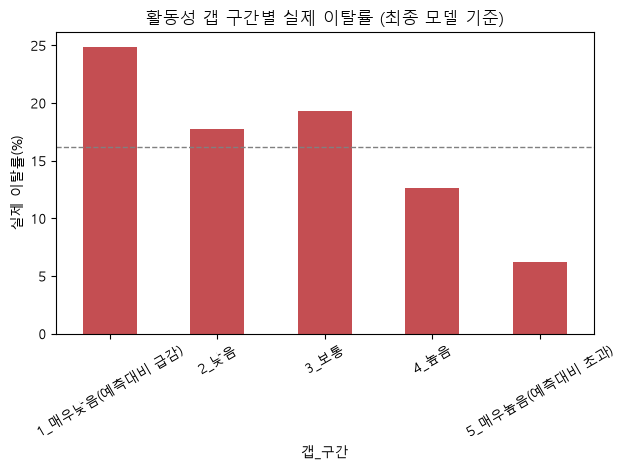

In [23]:
gap_df["갭_구간"] = pd.qcut(
    gap_df["활동성_갭"], q=5,
    labels=["1_매우낮음(예측대비 급감)", "2_낮음", "3_보통", "4_높음", "5_매우높음(예측대비 초과)"]
)

churn_rate_by_gap = gap_df.groupby("갭_구간", observed=True)["실제_이탈여부"].mean() * 100
print("갭 구간별 실제 이탈률(%):")
print(churn_rate_by_gap.round(1))

churn_rate_by_gap.plot(kind="bar", color="#C44E52", rot=30)
plt.ylabel("실제 이탈률(%)")
plt.title("활동성 갭 구간별 실제 이탈률 (최종 모델 기준)")
plt.axhline(gap_df["실제_이탈여부"].mean()*100, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

c:\Users\UK\SKN34-2nd-4Team\project_venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


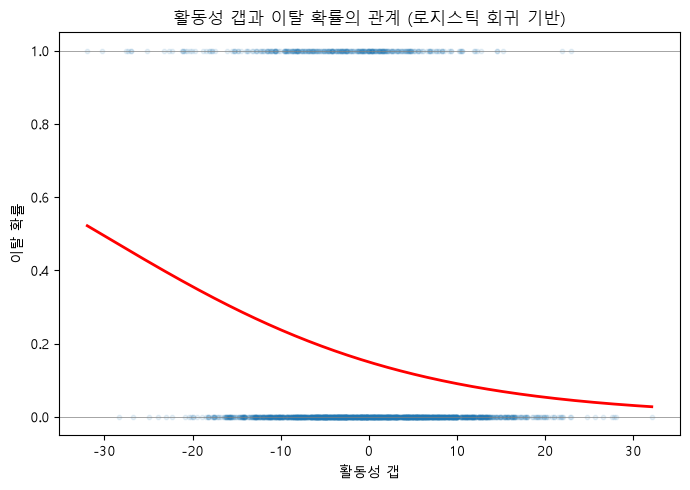

In [26]:
import numpy as np

# 갭 범위를 촘촘하게 나눠서 예측 확률 계산
gap_range = np.linspace(gap_df["활동성_갭"].min(), gap_df["활동성_갭"].max(), 300).reshape(-1, 1)
predicted_prob = lr_check.predict_proba(gap_range)[:, 1]

plt.figure(figsize=(7, 5))
plt.scatter(gap_df["활동성_갭"], gap_df["실제_이탈여부"], alpha=0.1, s=10)
plt.plot(gap_range, predicted_prob, color="red", linewidth=2)
plt.xlabel("활동성 갭")
plt.ylabel("이탈 확률")
plt.title("활동성 갭과 이탈 확률의 관계 (로지스틱 회귀 기반)")
plt.ylim(-0.05, 1.05)  # 0~1 범위 명확히 표시
plt.axhline(0, color="gray", linewidth=0.5)
plt.axhline(1, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

## 정리

- 베이스라인 확인 → **고도화(피처 엔지니어링 → 하이퍼파라미터 튜닝 → 앙상블)** → 최종 모델 확정 → 비즈니스 적용까지 하나의 Train/Validation/Test 기준으로 일관되게 진행함.
- 모든 후보 모델의 Val R²와 Test R²를 함께 표기해, Validation 대비 Test에서 성능이 크게 떨어지는지(과적합 여부) 함께 확인할 수 있도록 함.
- Test셋은 6번 섹션에서 전체 후보를 대상으로 단 한 번만 평가했으며, 이후 파라미터를 다시 조정하지 않음.
- 최종 모델 기준 활동성 갭으로 조기경보(위험군)와 우량 고객 발굴(안전군) 양쪽을 동시에 도출함.